# Phase 1 — Data Generation

This notebook explores the LTE network simulation (v3) that produced the training dataset.

**What's covered:**
- Network layout (base station positions)
- Radio model — 3GPP TR 36.873 UMa LOS/NLOS path loss, Gudmundson shadow fading, fast fading
- L3 EMA measurement filter and load-weighted SINR
- UE mobility — Random Waypoint with direction persistence (pedestrian + vehicle)
- A3/A4/A5 handover events, velocity-aware TTT, multi-factor failure probability
- Dataset statistics and label balance

In [1]:
import sys, math
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA = '../data/raw/dataset.csv'
df = pd.read_csv(DATA)
print(f'Shape: {df.shape}')
df.head()

Shape: (27000, 26)


,timestamp,ue_id,serving_cell_id,rsrp_serving,rsrq_serving,sinr,cqi,best_neighbor_cell_id,rsrp_neighbor,rsrq_neighbor,...,los_flag,serving_cell_load,cell_load_pct,handover_event,target_cell_id,event_type,handover_failure,ping_pong,rlf_flag,handover_soon
0,0,0,2,-70.09,-3.0,7.16,7,3,-78.26,-9.02,...,0,3,30.0,0,-1,none,0,0,0,0
1,1,0,2,-70.99,-3.0,9.19,8,3,-82.91,-12.60,...,0,3,30.0,0,-1,none,0,0,0,0
2,2,0,2,-61.02,-3.0,13.40,10,3,-76.47,-15.58,...,0,3,30.0,0,-1,none,0,0,0,0
3,3,0,2,-60.11,-3.0,16.78,12,3,-79.21,-19.17,...,0,3,30.0,0,-1,none,0,0,0,0
4,4,0,2,-65.77,-3.0,12.58,10,3,-72.34,-7.55,...,0,3,30.0,0,-1,none,0,0,0,0


## 1. Network Layout

4 base stations are placed at symmetric positions on a 1000 × 1000 m grid.

| BS | X (m) | Y (m) |
|----|-------|-------|
| 0  | 250   | 250   |
| 1  | 750   | 250   |
| 2  | 250   | 750   |
| 3  | 750   | 750   |

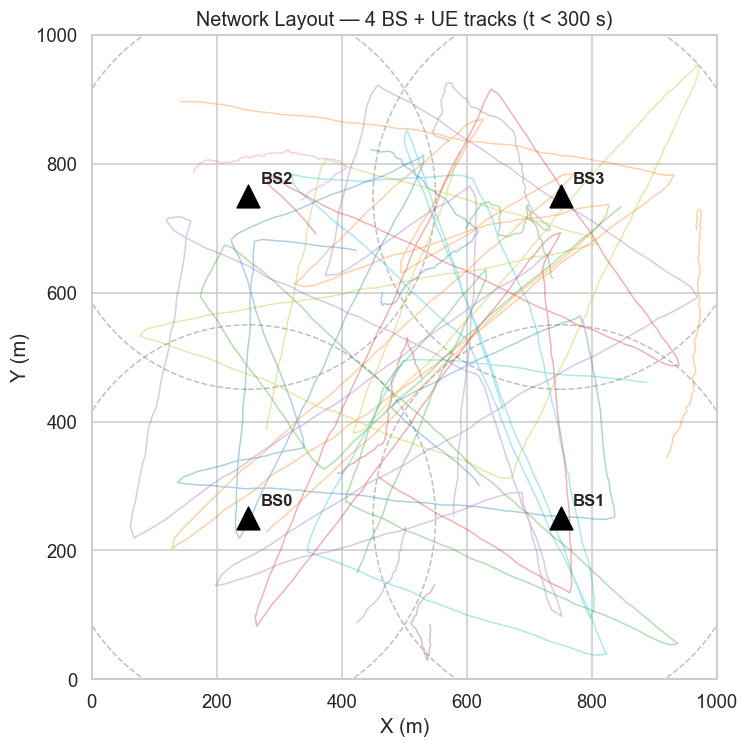

In [2]:
BS_POSITIONS = {0: (250, 250), 1: (750, 250), 2: (250, 750), 3: (750, 750)}
COLORS = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(7, 7))

# UE tracks (first 300 steps for clarity)
sample = df[df['timestamp'] < 300]
for ue_id in sorted(sample['ue_id'].unique()):
    ue = sample[sample['ue_id'] == ue_id]
    ax.plot(ue['pos_x'], ue['pos_y'], alpha=0.35, lw=1, color=COLORS[ue_id % 10])

# Base stations
for bs_id, (bx, by) in BS_POSITIONS.items():
    ax.scatter(bx, by, s=220, marker='^', color='black', zorder=5)
    ax.annotate(f'BS{bs_id}', (bx, by), textcoords='offset points',
                xytext=(8, 8), fontsize=11, fontweight='bold')
    circle = plt.Circle((bx, by), 300, fill=False,
                         linestyle='--', linewidth=1, color='gray', alpha=0.5)
    ax.add_patch(circle)

ax.set_xlim(0, 1000); ax.set_ylim(0, 1000)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Network Layout — 4 BS + UE tracks (t < 300 s)', fontsize=13)
plt.tight_layout(); plt.show()

## 2. Radio Model (`src/radio_model.py`)

**Path loss** — 3GPP TR 36.873 UMa, separate LOS and NLOS formulas (2 GHz):

$$PL_{\text{LOS}}(d) = 22\log_{10}(d) + 28 + 20\log_{10}(f_c) \quad [\text{dB}]$$

$$PL_{\text{NLOS}}(d) = \max\!\left(PL_{\text{LOS}},\ 19.55 + 39.09\log_{10}(d)\right)$$

The NLOS exponent (39) is significantly steeper than LOS (22), producing deep coverage holes at cell edges — the main reason A5 events are common in v3.

**LOS probability** (distance-dependent, 3GPP TR 36.873):

$$P(\text{LOS}|d) = \min\!\left(\tfrac{18}{d},1\right)\!\left(1-e^{-d/63}\right) + e^{-d/63}$$

d=100 m → 35% LOS · d=300 m → 8% LOS · d=500 m → 4% LOS

**L3 measurement filter** — EMA applied to raw RSRP before HO logic (α = 0.5):

$$\text{L3\_RSRP}_t = 0.5\cdot\text{RSRP}_t + 0.5\cdot\text{L3\_RSRP}_{t-1}$$

**SINR** — computed from L3-filtered RSRP with load-weighted interference:

$$\text{SINR} = \frac{S_{L3}}{\sum_k P_{k,L3}\cdot(0.10 + 0.90\cdot\text{load}_k) + N}$$

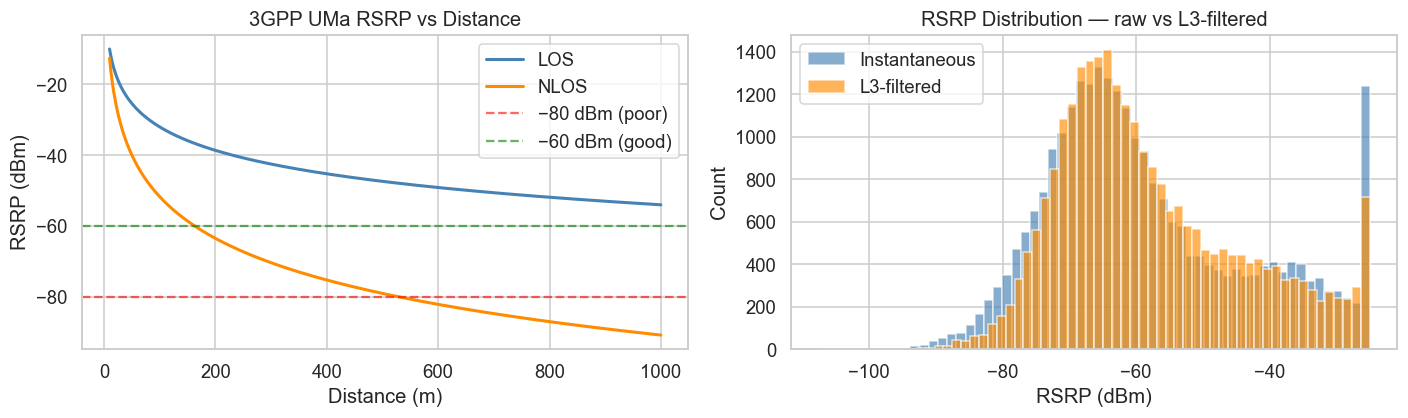

In [3]:
d = np.linspace(10, 1000, 500)
fc = 2.0

# v3 path loss: 3GPP TR 36.873 UMa LOS and NLOS
pl_los  = 22 * np.log10(np.maximum(d, 1)) + 28 + 20 * np.log10(fc)
pl_nlos = np.maximum(pl_los, 19.55 + 39.09 * np.log10(np.maximum(d, 1)))
rsrp_los  = 46 - pl_los
rsrp_nlos = 46 - pl_nlos

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(d, rsrp_los,  color='steelblue',  lw=2, label='LOS')
axes[0].plot(d, rsrp_nlos, color='darkorange', lw=2, label='NLOS')
axes[0].axhline(-80, ls='--', color='red',   alpha=0.6, label='−80 dBm (poor)')
axes[0].axhline(-60, ls='--', color='green', alpha=0.6, label='−60 dBm (good)')
axes[0].set_xlabel('Distance (m)'); axes[0].set_ylabel('RSRP (dBm)')
axes[0].set_title('3GPP UMa RSRP vs Distance'); axes[0].legend()

axes[1].hist(df['rsrp_serving'],   bins=60, color='steelblue',  alpha=0.65,
             edgecolor='white', label='Instantaneous')
axes[1].hist(df['l3_rsrp_serving'], bins=60, color='darkorange', alpha=0.65,
             edgecolor='white', label='L3-filtered')
axes[1].set_xlabel('RSRP (dBm)'); axes[1].set_ylabel('Count')
axes[1].set_title('RSRP Distribution — raw vs L3-filtered')
axes[1].legend()

plt.tight_layout(); plt.show()

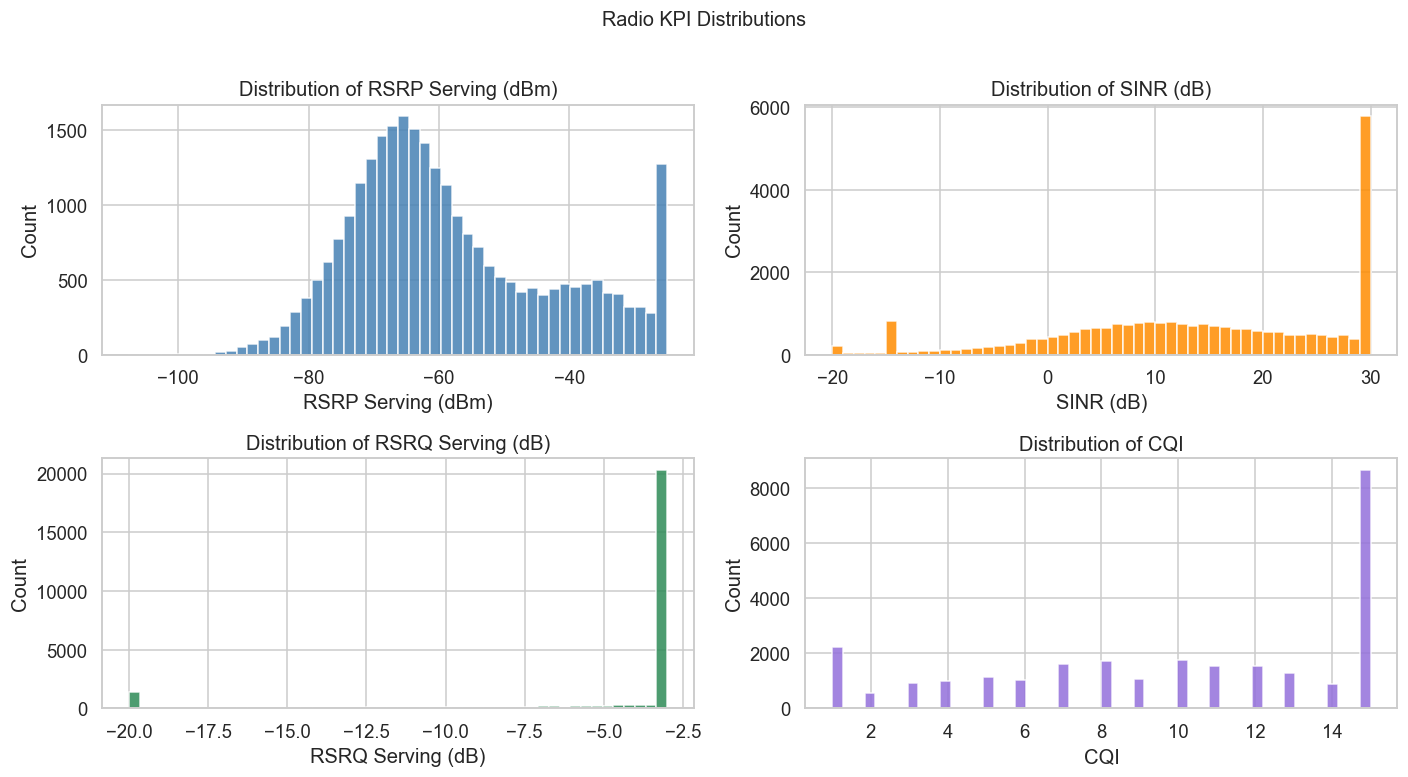

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
pairs = [
    ('rsrp_serving', 'RSRP Serving (dBm)', 'steelblue'),
    ('sinr',         'SINR (dB)',           'darkorange'),
    ('rsrq_serving', 'RSRQ Serving (dB)',   'seagreen'),
    ('cqi',          'CQI',                 'mediumpurple'),
]
for ax, (col, label, c) in zip(axes.flat, pairs):
    ax.hist(df[col], bins=50, color=c, edgecolor='white', alpha=0.85)
    ax.set_xlabel(label); ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {label}')
plt.suptitle('Radio KPI Distributions', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 3. UE Mobility (`src/mobility.py`)

Random Waypoint model with direction persistence:

- **Pedestrian UEs (0–7):** 0.5–2 m/s · short waypoints (200 m radius) · 50% heading blend toward target · heading noise σ=0.30 rad · pause 0–10 s on arrival
- **Vehicle UEs (8–14):** 8–20 m/s · full-grid waypoints · 80% heading blend · heading noise σ=0.06 rad · no pause

Each step the heading blends toward the current waypoint then adds Gaussian noise, producing curvilinear trajectories. Boundary: elastic reflection off grid edges.

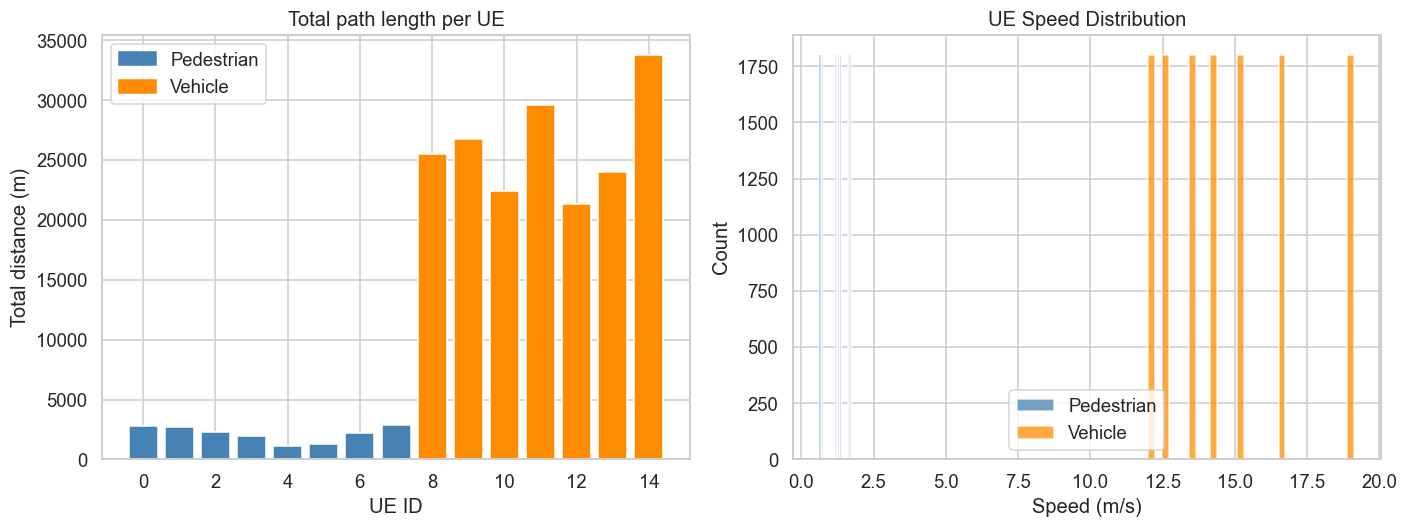

In [5]:
speed_profile = df[['ue_id','ue_speed']].drop_duplicates('ue_id').set_index('ue_id')['ue_speed']
ue_types = ['Vehicle' if s > 3 else 'Pedestrian' for s in speed_profile]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trajectory length comparison
traj_len = df.groupby('ue_id').apply(
    lambda g: np.sqrt(np.diff(g['pos_x'])**2 + np.diff(g['pos_y'])**2).sum()
)
colors_bar = ['darkorange' if t == 'Vehicle' else 'steelblue' for t in ue_types]
axes[0].bar(speed_profile.index, traj_len.values, color=colors_bar)
axes[0].set_xlabel('UE ID'); axes[0].set_ylabel('Total distance (m)')
axes[0].set_title('Total path length per UE')
patches = [mpatches.Patch(color='steelblue', label='Pedestrian'),
           mpatches.Patch(color='darkorange', label='Vehicle')]
axes[0].legend(handles=patches)

# Speed distribution
axes[1].hist(df[df['ue_speed'] < 5]['ue_speed'],  bins=30, label='Pedestrian',
             color='steelblue', alpha=0.75, edgecolor='white')
axes[1].hist(df[df['ue_speed'] >= 5]['ue_speed'], bins=30, label='Vehicle',
             color='darkorange', alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Speed (m/s)'); axes[1].set_ylabel('Count')
axes[1].set_title('UE Speed Distribution'); axes[1].legend()

plt.tight_layout(); plt.show()

## 4. Handover Logic (`src/handover_logic.py`)

**Event classification** (on L3-filtered RSRP, priority A5 > A4 > A3):

| Event | Condition | Meaning |
|-------|-----------|---------|
| **A5** | `L3_srv < −68 dBm` AND `L3_nb > −60 dBm` | Coverage emergency |
| **A4** | `L3_nb > −55 dBm` | Strong target available |
| **A3** | `L3_nb > L3_srv + 3 dB` | Standard best-server reselection |

**Velocity-aware TTT** — faster UEs get shorter time-to-trigger:

$$TTT = \max\!\left(1,\ 3 - \left\lfloor\frac{v}{7}\right\rfloor\right) \text{ steps}$$

Vehicle at 14 m/s → TTT=1 step; pedestrian at 1 m/s → TTT=3 steps.

**Multi-factor HO failure probability:**

$$P(\text{fail}) = 0.50\cdot p_{\text{SINR}} + 0.15\cdot p_{\text{speed}} + 0.15\cdot p_{\text{target}} + 0.20\cdot p_{\text{sustained}}$$

Overall failure rate in dataset: ~20%.

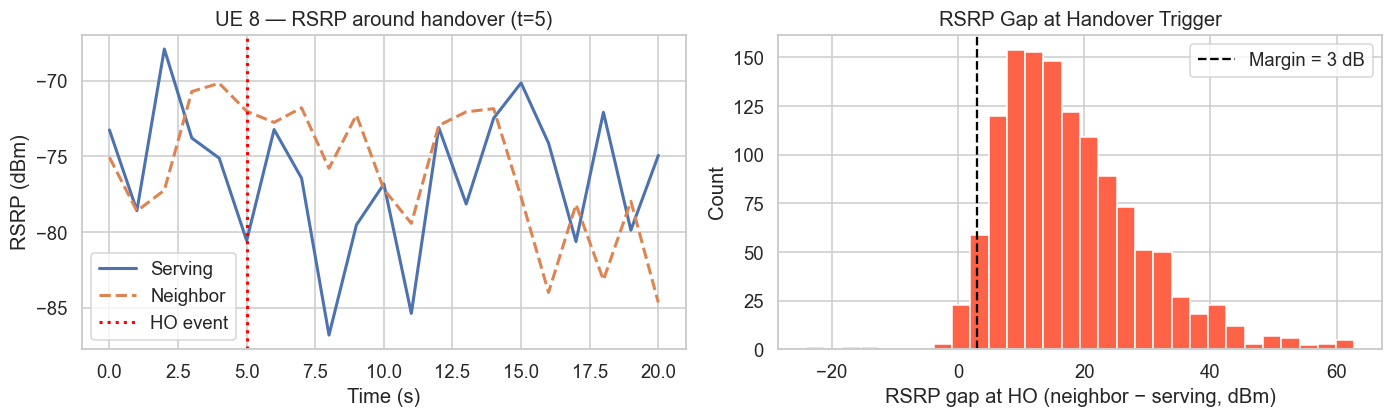

In [6]:
ho = df[df['handover_event'] == 1].copy()
ho['rsrp_gap'] = ho['rsrp_neighbor'] - ho['rsrp_serving']

# RSRP trace for one vehicle UE around a handover
vehicle_ues = df[df['ue_speed'] > 3]['ue_id'].unique()
ue_ho = ho[ho['ue_id'].isin(vehicle_ues)]
if len(ue_ho) > 0:
    example_ue = int(ue_ho['ue_id'].iloc[0])
    example_t  = int(ue_ho['timestamp'].iloc[0])
    window = df[(df['ue_id'] == example_ue) &
                (df['timestamp'].between(example_t - 15, example_t + 15))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(window['timestamp'], window['rsrp_serving'],  label='Serving',  lw=2)
    axes[0].plot(window['timestamp'], window['rsrp_neighbor'], label='Neighbor', lw=2, ls='--')
    ho_rows = window[window['handover_event'] == 1]
    axes[0].axvline(example_t, color='red', ls=':', lw=2, label='HO event')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('RSRP (dBm)')
    axes[0].set_title(f'UE {example_ue} — RSRP around handover (t={example_t})')
    axes[0].legend()

    axes[1].hist(ho['rsrp_gap'], bins=30, color='tomato', edgecolor='white')
    axes[1].axvline(3, ls='--', color='black', label='Margin = 3 dB')
    axes[1].set_xlabel('RSRP gap at HO (neighbor − serving, dBm)')
    axes[1].set_ylabel('Count'); axes[1].set_title('RSRP Gap at Handover Trigger')
    axes[1].legend()

    plt.tight_layout(); plt.show()

## 5. Dataset Statistics & Label Balance

In [7]:
print('=== Dataset Overview ===')
print(f'Rows          : {len(df):,}')
print(f'Columns       : {len(df.columns)}')
print(f'UEs           : {df["ue_id"].nunique()}')
print(f'Timesteps     : {df["timestamp"].nunique()}')

ho = df[df['handover_event'] == 1]
print(f'\nHandover attempts  : {len(ho)}')
print(f'  Successful       : {(ho["handover_failure"]==0).sum()}  ({100*(ho["handover_failure"]==0).mean():.1f}%)')
print(f'  Failed (RLF)     : {ho["handover_failure"].sum()}  ({100*ho["handover_failure"].mean():.1f}%)')
print(f'  Ping-pong        : {ho["ping_pong"].sum()}  ({100*ho["ping_pong"].mean():.1f}%)')
print(f'\nEvent type split:')
for ev, cnt in ho['event_type'].value_counts().items():
    print(f'  {ev}: {cnt}  ({100*cnt/len(ho):.1f}%)')

print(f'\nhandover_soon=1 : {df["handover_soon"].sum():,}  ({df["handover_soon"].mean()*100:.1f}%)')
print(f'LOS fraction    : {df["los_flag"].mean()*100:.1f}%')

print('\n=== Signal Ranges ===')
cols = ['rsrp_serving', 'l3_rsrp_serving', 'sinr', 'cqi', 'rsrp_neighbor', 'cell_load_pct', 'ue_speed']
print(df[cols].agg(['min','max','mean']).round(2))

=== Dataset Overview ===
Rows          : 27,000
Columns       : 26
UEs           : 15
Timesteps     : 1800

Handover attempts  : 1263
  Successful       : 1009  (79.9%)
  Failed (RLF)     : 254  (20.1%)
  Ping-pong        : 340  (26.9%)

Event type split:
  A3: 729  (57.7%)
  A5: 285  (22.6%)
  A4: 249  (19.7%)

handover_soon=1 : 2,964  (11.0%)
LOS fraction    : 21.4%

=== Signal Ranges ===
      rsrp_serving  l3_rsrp_serving  sinr    cqi  rsrp_neighbor  \
min        -107.56          -104.82 -20.0   1.00         -97.32   
max         -25.00           -25.00  30.0  15.00         -25.00   
mean        -58.34           -57.90  14.2   9.95         -70.72   

      cell_load_pct  ue_speed  
min            10.0      0.63  
max           100.0     19.13  
mean           44.8      7.57  


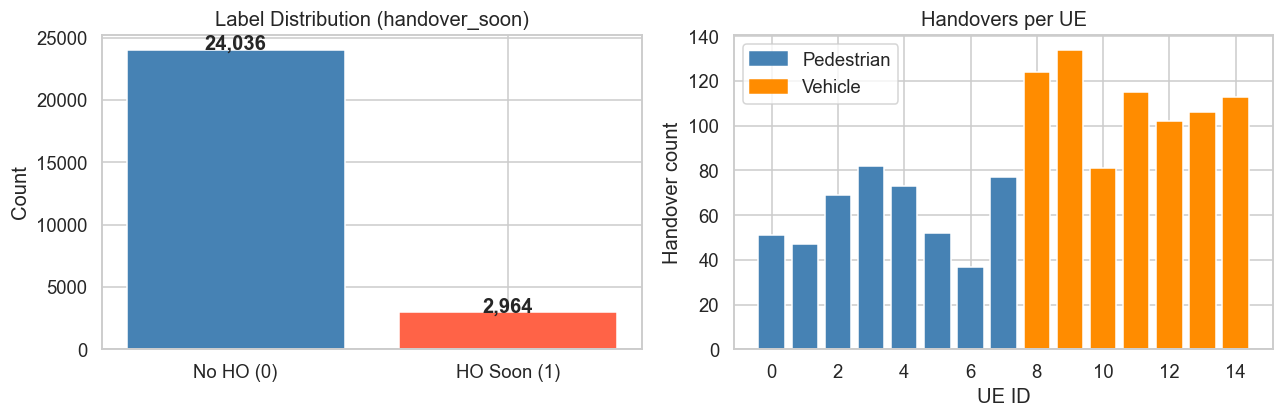

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = df['handover_soon'].value_counts()
axes[0].bar(['No HO (0)', 'HO Soon (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Label Distribution (handover_soon)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# HO events per UE
ho_per_ue = df.groupby('ue_id')['handover_event'].sum()
speed_map = df[['ue_id','ue_speed']].drop_duplicates('ue_id').set_index('ue_id')['ue_speed']
bar_colors = ['darkorange' if speed_map[u] > 3 else 'steelblue' for u in ho_per_ue.index]
axes[1].bar(ho_per_ue.index, ho_per_ue.values, color=bar_colors)
axes[1].set_xlabel('UE ID'); axes[1].set_ylabel('Handover count')
axes[1].set_title('Handovers per UE')
axes[1].legend(handles=[
    mpatches.Patch(color='steelblue', label='Pedestrian'),
    mpatches.Patch(color='darkorange', label='Vehicle')])

plt.tight_layout(); plt.show()

## Summary

| Item | Value |
|------|-------|
| Dataset rows | 27,000 |
| Columns | 26 |
| Positive labels (`handover_soon=1`) | 11.0% |
| Handover attempts | 1,263 |
| HO failure rate | 20.1% |
| Event split | A3: 57.7% · A4: 19.7% · A5: 22.6% |
| LOS fraction | 21.4% |
| RSRP range | −108 to −25 dBm |
| SINR range | −20 to +30 dB |

Vehicle UEs generate far more handovers due to faster cell-boundary crossings. The higher A5 share (22.6% vs ~6% in v2) reflects the steeper NLOS path loss exponent in the v3 3GPP UMa model.

→ **Next:** [02_feature_engineering.ipynb](02_feature_engineering.ipynb)